In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Directories
# ============================================================

DATA_DIR  = "../outputs/datasets/"
MODEL_DIR = "../outputs/models/"
PRED_DIR  = "../outputs/models/predictions/"
PLOT_DIR  = "../outputs/models/plots/"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# ============================================================
# Regression Targets
# ============================================================

TARGETS = {
    "Throughput": "Perf_Avg_Throughput",
    "Latency":    "Perf_Avg_Latency",
    "Loss":       "Perf_Avg_Loss",
}

EXCLUDE = [
    "StartDateTime", "EndDateTime",
    "Perf_Filename", "ND_Filename",
    "RunDateTime"
]

plt.style.use("seaborn-v0_8-whitegrid")

# ============================================================
# 1. Load Dataset and Prepare Tensors
# ============================================================

def load_split_data():
    df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    df_valid = pd.read_csv(os.path.join(DATA_DIR, "valid.csv"))
    df_test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
    return df_train, df_valid, df_test


def extract_xy(df):
    """Auto-detect numeric feature columns and extract all ML model inputs."""

    df = df.drop(columns=[c for c in EXCLUDE if c in df.columns], errors="ignore")

    df_num = df.select_dtypes(include=[np.number])

    feature_cols = [c for c in df_num.columns if c not in TARGETS.values()]

    X = df_num[feature_cols].fillna(0).values.astype(np.float32)
    y = {name: df_num[col].fillna(0).values.astype(np.float32) for name, col in TARGETS.items()}

    return X, y, feature_cols


# ============================================================
# 2. MLP Model Definition
# ============================================================

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# 3. Training Function
# ============================================================

def train_single_mlp(X_train, y_train, X_valid, y_valid, model_name, input_dim,
                     epochs=80, batch_size=64, lr=1e-3):

    """Train an MLP for one metric (throughput, latency, loss)."""

    print(f"\n====================== MLP MODEL: {model_name} ======================")

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = MLP(input_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train).unsqueeze(1))
    valid_ds = TensorDataset(torch.tensor(X_valid), torch.tensor(y_valid).unsqueeze(1))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size)

    train_losses, valid_losses = [], []
    best_loss = float("inf")
    patience, patience_limit = 0, 15

    # --------------------- TRAIN LOOP ---------------------
    for epoch in range(epochs):
        model.train()
        total_train = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_train += loss.item()

        train_losses.append(total_train / len(train_loader))

        # --------------------- VALIDATION ---------------------
        model.eval()
        total_valid = 0

        with torch.no_grad():
            for xb, yb in valid_loader:
                xb, yb = xb.to(device), yb.to(device)

                pred = model(xb)
                loss = loss_fn(pred, yb)

                total_valid += loss.item()

        valid_loss = total_valid / len(valid_loader)
        valid_losses.append(valid_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train: {train_losses[-1]:.4f} | Valid: {valid_loss:.4f}")

        # Early stopping
        if valid_loss < best_loss:
            best_loss = valid_loss
            patience = 0
            best_model = model.state_dict()
        else:
            patience += 1
            if patience >= patience_limit:
                print("Early stopping triggered!")
                break

    model.load_state_dict(best_model)

    # Save Model
    model_path = os.path.join(MODEL_DIR, f"mlp_model_{model_name.lower()}.pt")
    torch.save(model.state_dict(), model_path)
    print(f"Saved → {model_path}")

    # Save Loss Curves
    curve_path = os.path.join(PLOT_DIR, f"mlp_{model_name}_loss_curve.png")
    plt.figure(figsize=(9, 5))
    plt.plot(train_losses, label="Train")
    plt.plot(valid_losses, label="Validation")
    plt.title(f"MLP Loss Curve – {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(curve_path, dpi=300)
    plt.close()
    print(f"Saved loss curve → {curve_path}")

    return model


# ============================================================
# 4. Prediction + Plotting
# ============================================================

def evaluate_mlp(model, X, y_true):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()

    with torch.no_grad():
        preds = model(torch.tensor(X).to(device)).cpu().numpy().flatten()

    return preds


def plot_pred_vs_actual(y_true, y_pred, title, outfile):
    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], "r--")

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.close()


def plot_time_series(y_true, y_pred, title, outfile):
    plt.figure(figsize=(10, 5))
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.legend()
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.close()


# ============================================================
# 5. Full Pipeline
# ============================================================

def train_mlp_pipeline():

    df_train, df_valid, df_test = load_split_data()

    X_train, y_train_dict, feature_cols = extract_xy(df_train)
    X_valid, y_valid_dict, _           = extract_xy(df_valid)
    X_test,  y_test_dict, _            = extract_xy(df_test)

    input_dim = X_train.shape[1]

    for model_name in TARGETS.keys():

        print(f"\n================ TRAINING MLP FOR {model_name} ================")

        model = train_single_mlp(
            X_train, y_train_dict[model_name],
            X_valid, y_valid_dict[model_name],
            model_name,
            input_dim
        )

        # Evaluate
        y_pred_valid = evaluate_mlp(model, X_valid, y_valid_dict[model_name])
        y_pred_test  = evaluate_mlp(model, X_test,  y_test_dict[model_name])

        # Save predictions
        pd.DataFrame({
            "y_true": y_valid_dict[model_name],
            "y_pred": y_pred_valid
        }).to_csv(os.path.join(PRED_DIR, f"mlp_{model_name}_valid_predictions.csv"), index=False)

        pd.DataFrame({
            "y_true": y_test_dict[model_name],
            "y_pred": y_pred_test
        }).to_csv(os.path.join(PRED_DIR, f"mlp_{model_name}_test_predictions.csv"), index=False)

        # Plots
        plot_pred_vs_actual(
            y_valid_dict[model_name], y_pred_valid,
            title=f"MLP – Predicted vs Actual ({model_name}, Valid)",
            outfile=os.path.join(PLOT_DIR, f"mlp_{model_name}_pred_valid.png")
        )

        plot_pred_vs_actual(
            y_test_dict[model_name], y_pred_test,
            title=f"MLP – Predicted vs Actual ({model_name}, Test)",
            outfile=os.path.join(PLOT_DIR, f"mlp_{model_name}_pred_test.png")
        )

        plot_time_series(
            y_valid_dict[model_name], y_pred_valid,
            title=f"MLP – Time Series ({model_name}, Valid)",
            outfile=os.path.join(PLOT_DIR, f"mlp_{model_name}_ts_valid.png")
        )

        plot_time_series(
            y_test_dict[model_name], y_pred_test,
            title=f"MLP – Time Series ({model_name}, Test)",
            outfile=os.path.join(PLOT_DIR, f"mlp_{model_name}_ts_test.png")
        )


In [2]:
# from mlp_training import train_mlp_pipeline
train_mlp_pipeline()



================ TRAINING MLP FOR Throughput ================

====================== MLP MODEL: Throughput ======================
Epoch 1/80 | Train: 62677.3828 | Valid: 341.3513
Epoch 2/80 | Train: 460.8269 | Valid: 29185.5566
Epoch 3/80 | Train: 32978.6406 | Valid: 28872.0098
Epoch 4/80 | Train: 32622.5840 | Valid: 9703.4355
Epoch 5/80 | Train: 11176.8721 | Valid: 56.4435
Epoch 6/80 | Train: 61.1555 | Valid: 6547.3032
Epoch 7/80 | Train: 6696.2773 | Valid: 15393.2725
Epoch 8/80 | Train: 16147.9092 | Valid: 15282.3369
Epoch 9/80 | Train: 16044.4688 | Valid: 7919.5063
Epoch 10/80 | Train: 8151.8062 | Valid: 1325.0967
Epoch 11/80 | Train: 1258.2869 | Valid: 345.9529
Epoch 12/80 | Train: 452.0988 | Valid: 3720.0374
Epoch 13/80 | Train: 4332.0962 | Valid: 6813.6309
Epoch 14/80 | Train: 7811.3765 | Valid: 6423.5371
Epoch 15/80 | Train: 7374.3564 | Valid: 3327.5085
Epoch 16/80 | Train: 3888.0488 | Valid: 537.4542
Epoch 17/80 | Train: 682.7888 | Valid: 224.8645
Epoch 18/80 | Train: 177.320

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PRED_DIR = "../outputs/models/predictions/"
PLOT_DIR = "../outputs/models/plots/"

os.makedirs(PLOT_DIR, exist_ok=True)

MODELS = ["Throughput", "Latency", "Loss"]

plt.style.use("seaborn-v0_8-whitegrid")


# ============================================================
# Load Prediction CSV
# ============================================================

def load_mlp_predictions(metric, split):
    """
    Loads dataframe:
    mlp_{metric}_{split}_predictions.csv
    """
    path = os.path.join(PRED_DIR, f"mlp_{metric}_{split}_predictions.csv")

    if not os.path.exists(path):
        raise FileNotFoundError(f"Prediction file missing → {path}")

    df = pd.read_csv(path)

    return df["y_true"], df["y_pred"]


# ============================================================
# Plot Predicted vs Actual
# ============================================================

def plot_pred_vs_actual(y_true, y_pred, title, outfile, showImage=False):

    plt.figure(figsize=(7, 6))

    sns.scatterplot(
        x=y_true,
        y=y_pred,
        alpha=0.6,
        edgecolor=None
    )

    # Identity line
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label="Ideal")

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outfile, dpi=300)

    if showImage:
        plt.show()
    else:
        plt.close()

    print(f"Saved → {outfile}")


# ============================================================
# Plot Time-Series
# ============================================================

def plot_time_series(y_true, y_pred, title, outfile, showImage=False):

    plt.figure(figsize=(10, 5))

    plt.plot(y_true.values, label="Actual", linewidth=2, color="blue")
    plt.plot(y_pred, label="Predicted", linewidth=2, linestyle="--", color="orange")

    plt.title(title)
    plt.xlabel("Sample Index")
    plt.ylabel("Value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(outfile, dpi=300)

    if showImage:
        plt.show()
    else:
        plt.close()

    print(f"Saved → {outfile}")


# ============================================================
# Generate ALL MLP Plots
# ============================================================

def generate_mlp_plots(showImage=False):

    for metric in MODELS:
        print(f"\n=== Generating MLP Plots for {metric} ===")

        # --------------------------------------
        # VALIDATION
        # --------------------------------------
        yv, yv_pred = load_mlp_predictions(metric, "valid")

        plot_pred_vs_actual(
            yv, yv_pred,
            title=f"MLP {metric} – Predicted vs Actual (Validation)",
            outfile=os.path.join(PLOT_DIR, f"mlp_{metric}_pred_vs_actual_valid.png"),
            showImage=showImage
        )

        plot_time_series(
            yv, yv_pred,
            title=f"MLP {metric} – Time-Series (Validation)",
            outfile=os.path.join(PLOT_DIR, f"mlp_{metric}_timeseries_valid.png"),
            showImage=showImage
        )

        # --------------------------------------
        # TEST
        # --------------------------------------
        yt, yt_pred = load_mlp_predictions(metric, "test")

        plot_pred_vs_actual(
            yt, yt_pred,
            title=f"MLP {metric} – Predicted vs Actual (Test)",
            outfile=os.path.join(PLOT_DIR, f"mlp_{metric}_pred_vs_actual_test.png"),
            showImage=showImage
        )

        plot_time_series(
            yt, yt_pred,
            title=f"MLP {metric} – Time-Series (Test)",
            outfile=os.path.join(PLOT_DIR, f"mlp_{metric}_timeseries_test.png"),
            showImage=showImage
        )

    print("\nAll MLP plots generated successfully!")



=== Generating MLP Plots for Throughput ===


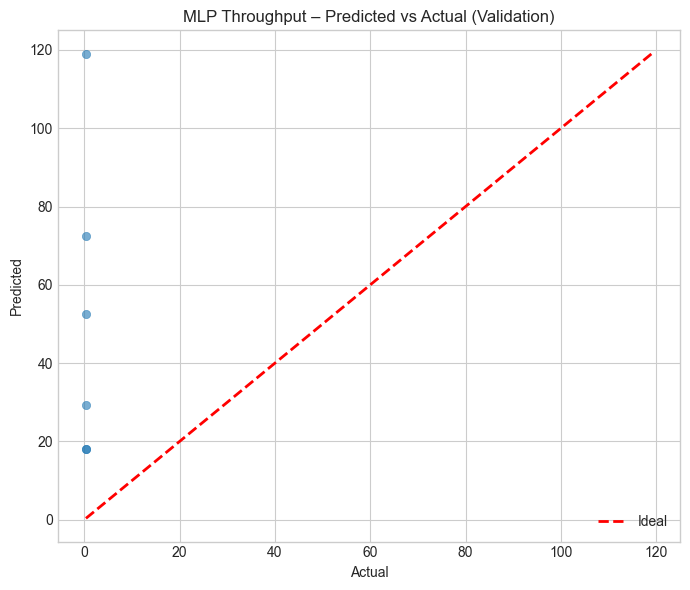

Saved → ../outputs/models/plots/mlp_Throughput_pred_vs_actual_valid.png


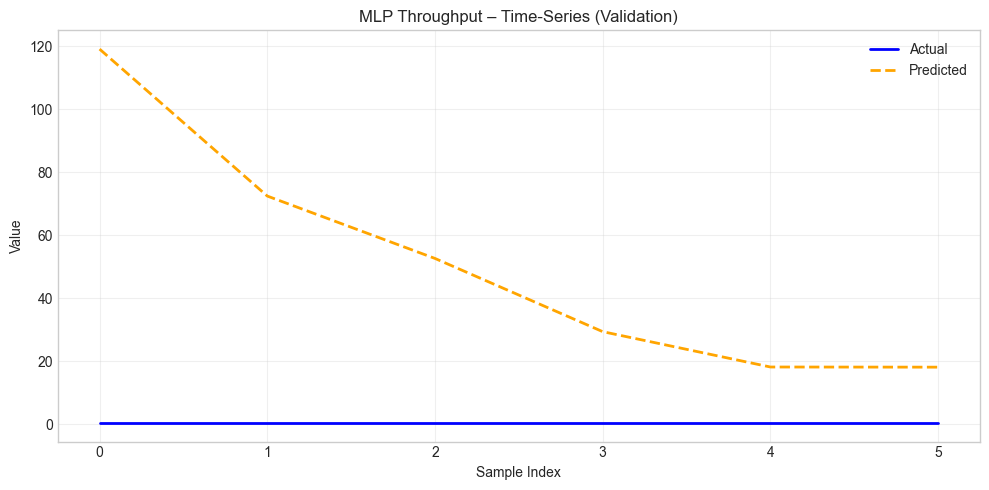

Saved → ../outputs/models/plots/mlp_Throughput_timeseries_valid.png


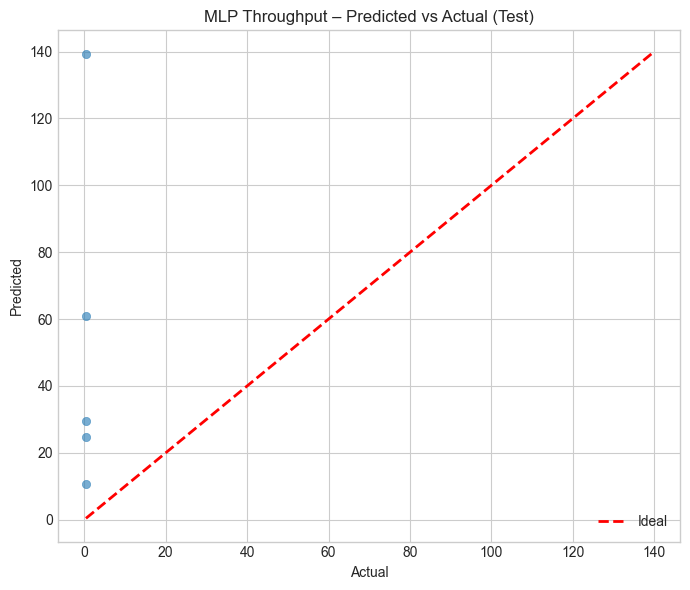

Saved → ../outputs/models/plots/mlp_Throughput_pred_vs_actual_test.png


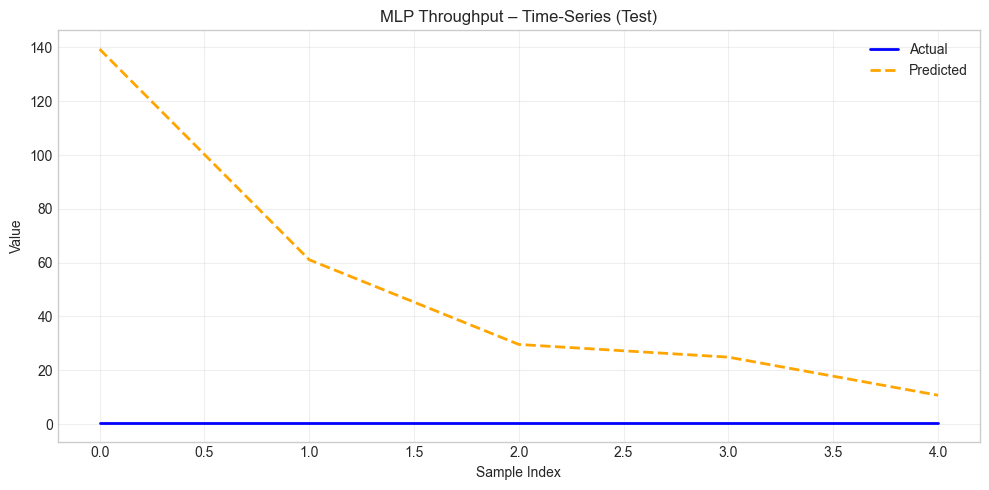

Saved → ../outputs/models/plots/mlp_Throughput_timeseries_test.png

=== Generating MLP Plots for Latency ===


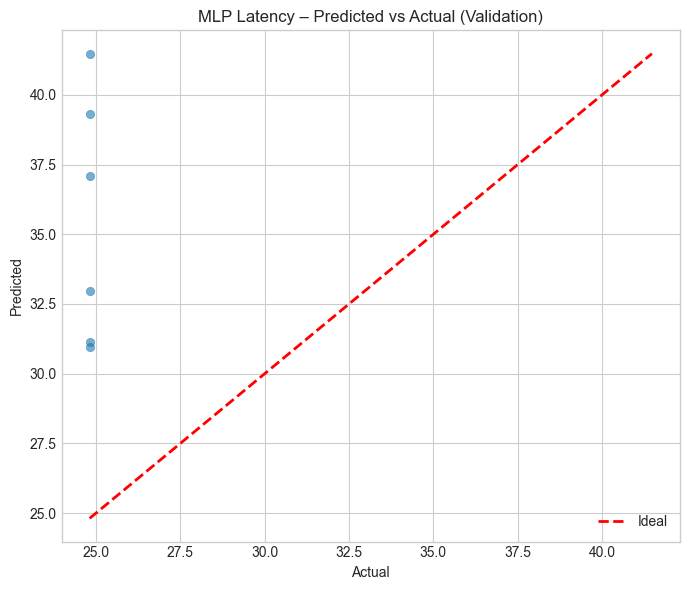

Saved → ../outputs/models/plots/mlp_Latency_pred_vs_actual_valid.png


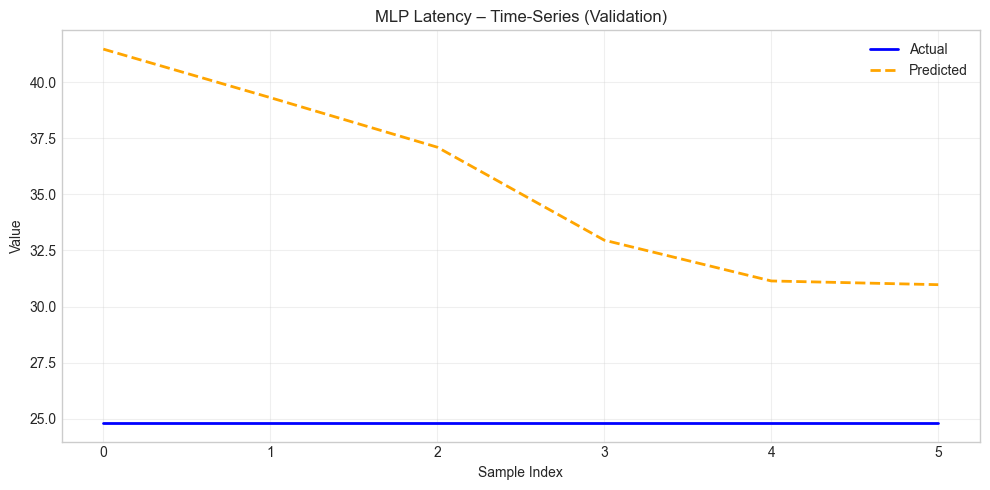

Saved → ../outputs/models/plots/mlp_Latency_timeseries_valid.png


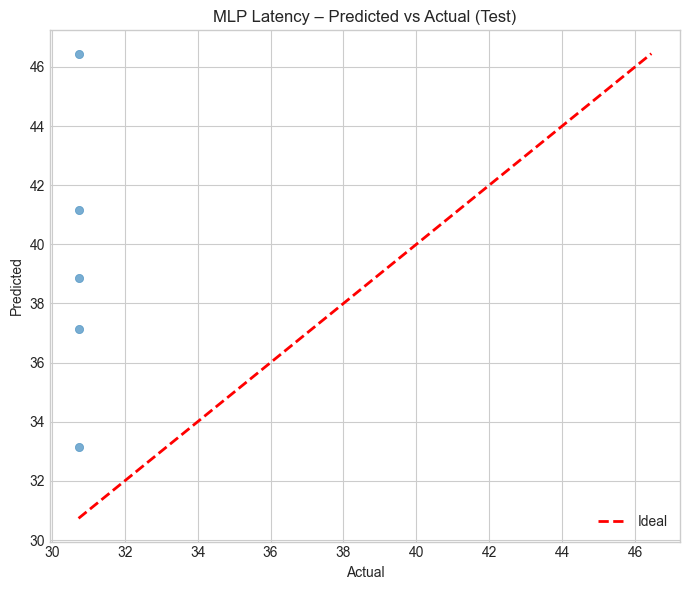

Saved → ../outputs/models/plots/mlp_Latency_pred_vs_actual_test.png


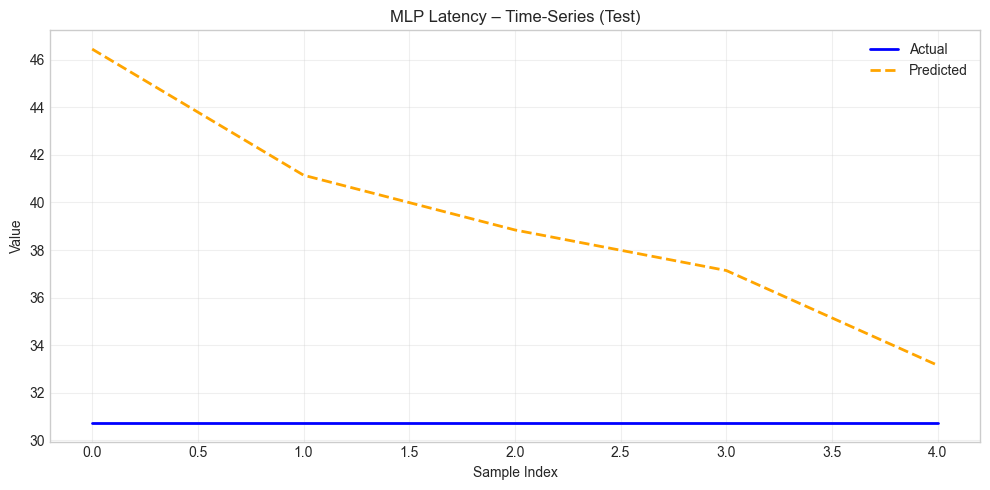

Saved → ../outputs/models/plots/mlp_Latency_timeseries_test.png

=== Generating MLP Plots for Loss ===


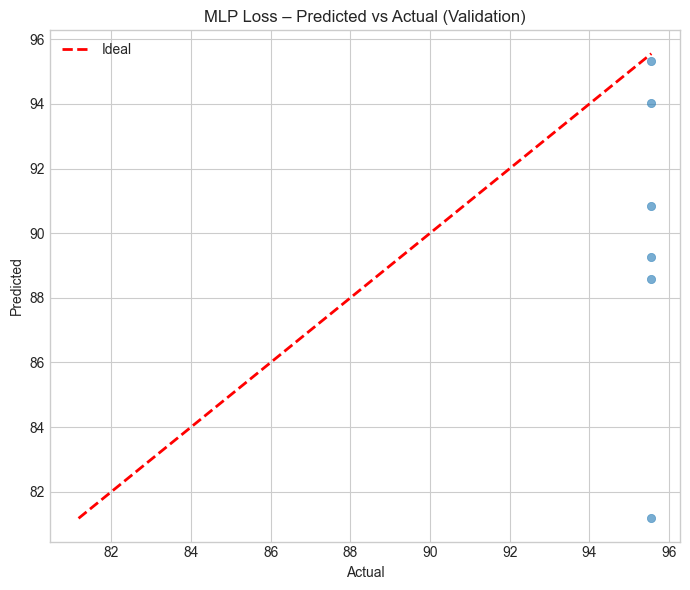

Saved → ../outputs/models/plots/mlp_Loss_pred_vs_actual_valid.png


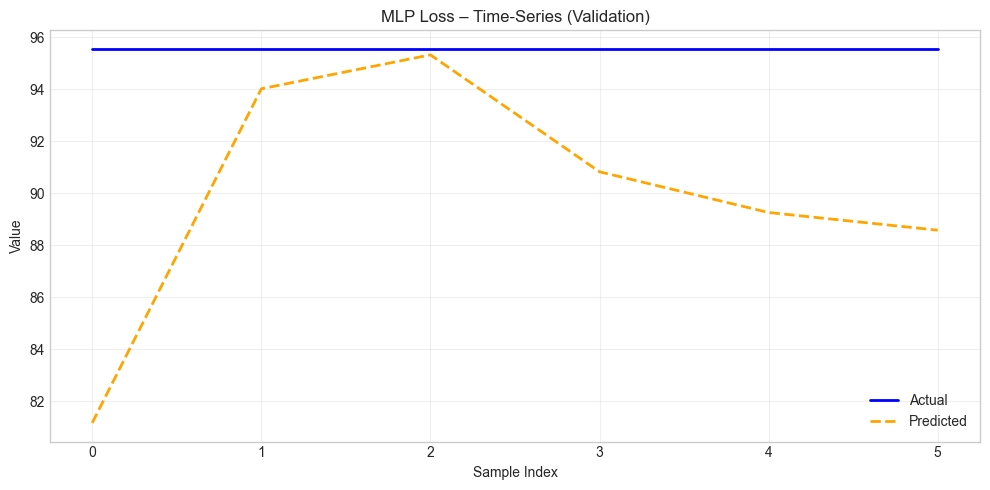

Saved → ../outputs/models/plots/mlp_Loss_timeseries_valid.png


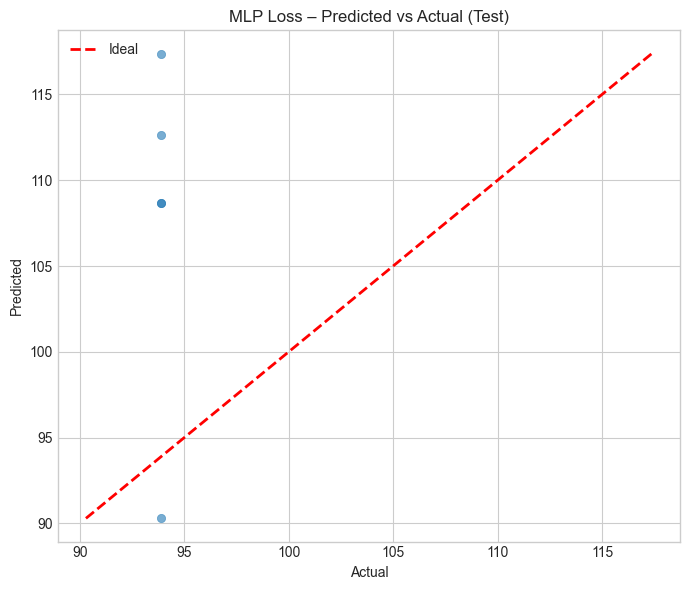

Saved → ../outputs/models/plots/mlp_Loss_pred_vs_actual_test.png


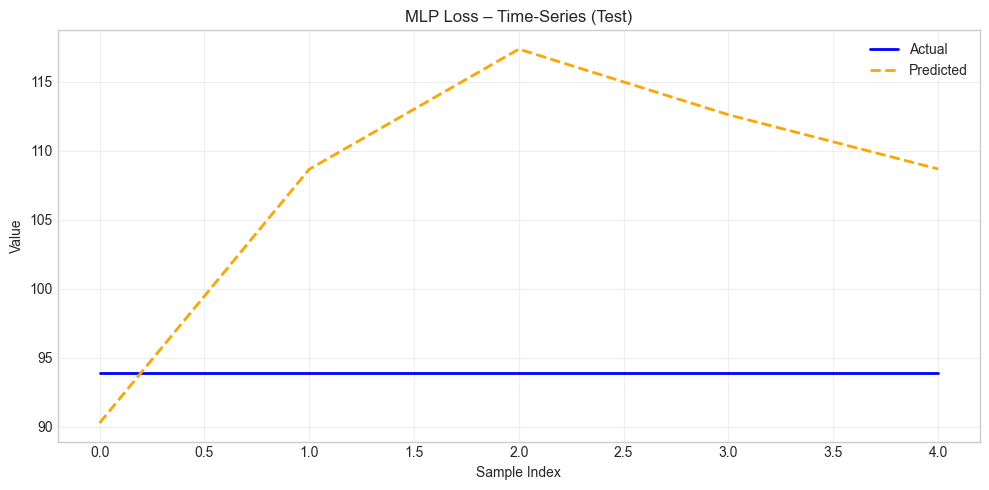

Saved → ../outputs/models/plots/mlp_Loss_timeseries_test.png

All MLP plots generated successfully!


In [5]:
# from mlp_plots import generate_mlp_plots
generate_mlp_plots(showImage=True)


In [6]:
import os
import time
import numpy as np
import torch
import torch.nn as nn


# ============================================================
# 1. Load MLP Model from Path
# ============================================================

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


def load_mlp_model(model_path, input_dim):
    """
    Load a saved MLP model (.pt) and return the PyTorch model object.
    """
    model = MLP(input_dim)
    state = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state)
    model.eval()
    return model


# ============================================================
# 2. Count Parameters & Model Size
# ============================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def model_size_bytes(model):
    """
    Size = number_of_parameters * 4 bytes (FP32)
    """
    return count_parameters(model) * 4


# ============================================================
# 3. FLOPs Estimation (exact for fully-connected MLP)
# ============================================================

def compute_mlp_flops(model, input_dim):
    """
    Count FLOPs for:
      - Linear layers: 2 * In * Out  (multiply + add)
      - Activations: negligible
    """

    flops = 0
    prev_dim = input_dim

    for layer in model.net:
        if isinstance(layer, nn.Linear):
            out_dim = layer.out_features
            flops += 2 * prev_dim * out_dim
            prev_dim = out_dim

    return flops


# ============================================================
# 4. Latency Measurement
# ============================================================

def measure_latency(model, example_input, runs=200, warmup=20):
    """
    Measures average inference latency in seconds.
    """
    device = "cpu"
    model.to(device)

    example_input = example_input.to(device)

    # Warmup
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(example_input)

        t0 = time.perf_counter()
        for _ in range(runs):
            _ = model(example_input)
        t1 = time.perf_counter()

    return (t1 - t0) / runs


# ============================================================
# 5. Energy Estimate
# ============================================================

def estimate_energy(latency_s, power_W=2.0):
    return latency_s * power_W


# ============================================================
# 6. Peak Activation Memory
# ============================================================

def estimate_peak_activation_memory(model, example_input):
    with torch.no_grad():
        out = model(example_input)
    return out.numel() * 4    # FP32


# ============================================================
# 7. Full MLP Edge Evaluation Pipeline
# ============================================================

def evaluate_mlp_edge(model_path, input_dim, assumed_power_W=2.0):
    """
    Main evaluation function.
    """

    # ------------------------------
    # Load model
    # ------------------------------
    model = load_mlp_model(model_path, input_dim)

    # Dummy input for evaluation
    example_input = torch.randn(1, input_dim)

    # ------------------------------
    # Compute metrics
    # ------------------------------
    params = count_parameters(model)
    size_b = model_size_bytes(model)
    size_mb = size_b / (1024 * 1024)

    flops = compute_mlp_flops(model, input_dim)
    latency = measure_latency(model, example_input)
    energy = estimate_energy(latency, assumed_power_W)
    peak_mem = estimate_peak_activation_memory(model, example_input)

    return {
        "Model Path": model_path,
        "Parameters": params,
        "Model Size (Bytes)": size_b,
        "Model Size (MB)": size_mb,
        "FLOPs": flops,
        "Latency (s)": latency,
        "Latency (ms)": latency * 1000,
        "Energy Estimated (J)": energy,
        "Peak Activation Memory (Bytes)": peak_mem
    }


In [7]:
# from mlp_edge_evaluation import evaluate_mlp_edge

input_dim = 103    # same as feature count
model_path = "../outputs/models/mlp_model_throughput.pt"

metrics = evaluate_mlp_edge(model_path, input_dim)

for k, v in metrics.items():
    print(f"{k}: {v}")


Model Path: ../outputs/models/mlp_model_throughput.pt
Parameters: 21633
Model Size (Bytes): 86532
Model Size (MB): 0.08252334594726562
FLOPs: 42880
Latency (s): 0.00010752350033726543
Latency (ms): 0.10752350033726543
Energy Estimated (J): 0.00021504700067453086
Peak Activation Memory (Bytes): 4
